# Full Dataset Exploration

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
original_df = pd.read_csv("../../data/processed/icu_corpus.csv")
final_df = pd.read_json("../../outputs/datasets/icu_entities_full.jsonl", lines=True)


In [83]:
print("Total number of notes processed:", original_df.shape[0])
print("Total number of entities extracted:", final_df.shape[0])

Total number of notes processed: 162296
Total number of entities extracted: 780941


In [84]:
print(f"Number of unique subjects in ICU corpus: {original_df['SUBJECT_ID'].nunique()}")
print(f"Number of unique subjects in final dataset: {final_df['subject_id'].nunique()}")

Number of unique subjects in ICU corpus: 25054
Number of unique subjects in final dataset: 8621


In [118]:
print(f"Number of unique reports in ICU corpus: {original_df.shape[0]}")
print(f"Number of unique reports in final dataset: {len(final_df['note_id'].unique())}")

percentage_reports_with_entities = ((final_df['note_id'].nunique() / original_df.shape[0]) * 100)
print(f"Percentage of reports with at least one entity extracted: {percentage_reports_with_entities:.2f}%")

Number of unique reports in ICU corpus: 162296
Number of unique reports in final dataset: 71917
Percentage of reports with at least one entity extracted: 44.31%


In [87]:
entities_per_report = final_df.groupby('note_id').size()
print("Statistics of number of entities extracted per report:\n")
print(entities_per_report.describe())

Statistics of number of entities extracted per report:

count    71917.000000
mean        10.858921
std         10.859676
min          1.000000
25%          3.000000
50%          7.000000
75%         16.000000
max         98.000000
dtype: float64


In [120]:
distribution = final_df["entity_type"].value_counts().to_frame(name="count")

distribution["percentage"] = (
    final_df["entity_type"].value_counts(normalize=True) * 100
).round(2)

print(distribution)

                     count  percentage
entity_type                           
INTERVENTION        334872       42.88
CLINICAL_CONDITION  280314       35.89
SYMPTOM             165755       21.23


In [129]:
final_df["is_valid"] = final_df["validation"].apply(lambda x: x["is_valid"])
number_valid = final_df["is_valid"].sum()
percentage_valid = final_df["is_valid"].mean() * 100
print(f"Number of valid entities: {number_valid}")
print(f"Percentage of valid entities: {percentage_valid:.2f}%")

Number of valid entities: 319852
Percentage of valid entities: 40.96%


In [135]:
final_df.groupby(["entity_type", "is_valid"]).size()

entity_type         is_valid
CLINICAL_CONDITION  False       194544
                    True         85770
INTERVENTION        False       161534
                    True        173338
SYMPTOM             False       105011
                    True         60744
dtype: int64

In [134]:
print("Percentage of valid entities by entity type:")
final_df.groupby("entity_type")["is_valid"].mean() * 100

Percentage of valid entities by entity type:


entity_type
CLINICAL_CONDITION    30.597830
INTERVENTION          51.762464
SYMPTOM               36.646858
Name: is_valid, dtype: float64

In [131]:
final_df["confidence"] = final_df["validation"].apply(lambda x: x["confidence"])
print("Statistics of confidence scores for extracted entities:\n")
final_df["confidence"].describe()

Statistics of confidence scores for extracted entities:



count    780941.000000
mean          0.505655
std           0.119858
min           0.170770
25%           0.414676
50%           0.507788
75%           0.609356
max           0.738348
Name: confidence, dtype: float64

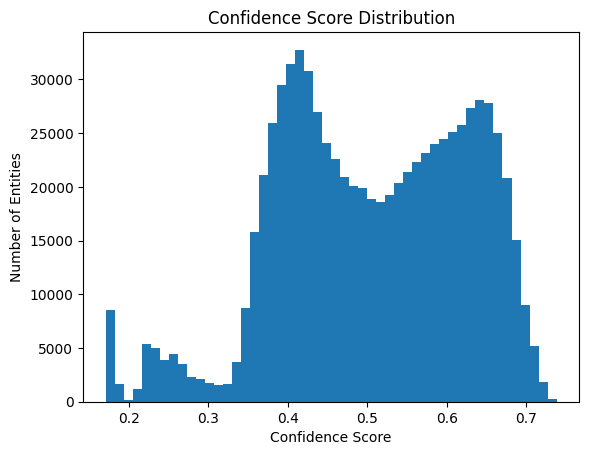

In [138]:
final_df["confidence"] = final_df["validation"].apply(lambda x: x["confidence"])

plt.figure()
plt.hist(final_df["confidence"], bins=50)
plt.title("Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Entities")
plt.show()